# Series Históricas
## PIB AGRÍCOLA | CONSUMO HOGARES | EXPORTACIONES
En este código se realizara el empalme y unión de las series de Banco de la República para dichos tres apartados. 

In [29]:
import pandas as pd

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def empalme_cascada(series_ajustadas, nombres_map, inicio, fin):
    for i in range(inicio, fin, -1):
        df_ref = series_ajustadas[i + 1]
        df_viej = globals()[nombres_map[i]].copy()

        comunes = set(df_ref['Año']) & set(df_viej['Año'])
        anio_pivote = max(comunes)

        factor = (
            df_ref.loc[df_ref['Año'] == anio_pivote, 'Valor'].values[0] /
            df_viej.loc[df_viej['Año'] == anio_pivote, 'Valor'].values[0]
        )

        df_viej['Valor'] = df_viej['Valor'] * factor
        series_ajustadas[i] = df_viej

    return series_ajustadas


def crecimiento_robusto(df, desde=1952, hasta=1960):
    df = df.sort_values('Año').copy()
    df = df[(df['Año'] >= desde) & (df['Año'] <= hasta)].copy()
    g = df['Valor'].pct_change().dropna()
    return g.median()


def unir_series(series_ajustadas, inicio, fin):
    panel_final = []
    for i in range(inicio, fin - 1, -1):
        df_temp = series_ajustadas[i]
        if not panel_final:
            panel_final.append(df_temp)
        else:
            anio_min_superior = pd.concat(panel_final)['Año'].min()
            panel_final.append(df_temp[df_temp['Año'] < anio_min_superior])
    return pd.concat(panel_final).sort_values('Año').reset_index(drop=True)


# ============================================================
# 1) AGROPECUARIO
# ============================================================
sectores_agro = [
    '1.01.01. Agropecuario, silvicultura, caza y pesca', 
    '1.01. Agropecuario', 
    '1.01.01. Agricultura, silvicultura, caza y pesca',
    '1.01.01. Agricultura, ganadería, caza, silvicultura\ny pesca'
]

for i in range(3, 9):
    df = pd.read_excel(f'File ({i}).xlsx', sheet_name='Series de datos', skiprows=1)
    df.dropna(subset=['Unnamed: 0'], inplace=True)
    df_f = df[df['Unnamed: 0'].isin(sectores_agro)].copy()
    df_f['Unnamed: 0'] = 'Agropecuario'

    df_l = pd.melt(df_f, id_vars=['Unnamed: 0'], var_name='Fecha', value_name='Valor')
    df_l.rename(columns={'Unnamed: 0': 'Sector'}, inplace=True)
    df_l['Fecha'] = pd.to_datetime(df_l['Fecha'], dayfirst=True, errors='coerce')
    df_l['Año'] = df_l['Fecha'].dt.year

    if i in [3, 4, 5]:
        globals()[f'df{i}_agro'] = df_l.sort_values('Año')
    else:
        df_a = df_l.resample('YE', on='Fecha').sum(numeric_only=True).reset_index()
        df_a['Año'] = df_a['Fecha'].dt.year
        globals()[f'df{i}_agro'] = df_a.sort_values('Año')

series_agro = {8: df8_agro.copy()}
map_agro = {7:'df7_agro',6:'df6_agro',5:'df5_agro',4:'df4_agro',3:'df3_agro'}
series_agro = empalme_cascada(series_agro, map_agro, 7, 3)

# EMPALME ROBUSTO
gt_agro = crecimiento_robusto(series_agro[4])
val_1950 = series_agro[4].loc[series_agro[4]['Año']==1950,'Valor'].values[0]
val_1949_adj = val_1950 / (1 + gt_agro)

df3 = df3_agro.copy()
v_1949 = df3.loc[df3['Año']==1949,'Valor'].values[0]
factor = val_1949_adj / v_1949
df3['Valor'] *= factor
series_agro[3] = df3

df_agro_final = unir_series(series_agro, 8, 3)


# ============================================================
# 2) CONSUMO HOGARES
# ============================================================
sectores_cons = [
    "1.03.01.1. Consumo total - hogares", 
    "1.02.02.1.1. Consumo final - gastos de consumo\nprivado",
    "1.02.01.1.1. Consumo final - hogares",
    "1.01.01.1. Consumo de Hogares",
    "1.02.01. Gasto de consumo final individual de los\nhogares; gasto de consumo final de las ISFLH"
]

for i in range(9, 15):
    df = pd.read_excel(f'File ({i}).xlsx', sheet_name='Series de datos', skiprows=1)
    df.dropna(subset=['Unnamed: 0'], inplace=True)
    df_f = df[df['Unnamed: 0'].isin(sectores_cons)].copy()
    df_f['Unnamed: 0'] = 'Consumo'

    df_l = pd.melt(df_f, id_vars=['Unnamed: 0'], var_name='Fecha', value_name='Valor')
    df_l.rename(columns={'Unnamed: 0': 'Sector'}, inplace=True)
    df_l['Fecha'] = pd.to_datetime(df_l['Fecha'], dayfirst=True, errors='coerce')
    df_l['Año'] = df_l['Fecha'].dt.year

    if i in [9,10,11]:
        globals()[f'df{i}_cons'] = df_l.sort_values('Año')
    else:
        df_a = df_l.resample('YE', on='Fecha').sum(numeric_only=True).reset_index()
        df_a['Año'] = df_a['Fecha'].dt.year
        globals()[f'df{i}_cons'] = df_a.sort_values('Año')

series_cons = {14: df14_cons.copy()}
map_cons = {13:'df13_cons',12:'df12_cons',11:'df11_cons',10:'df10_cons',9:'df9_cons'}
series_cons = empalme_cascada(series_cons, map_cons, 13, 9)

gt_cons = crecimiento_robusto(series_cons[10])
val_1950 = series_cons[10].loc[series_cons[10]['Año']==1950,'Valor'].values[0]
val_1949_adj = val_1950 / (1 + gt_cons)

df9 = df9_cons.copy()
v_1949 = df9.loc[df9['Año']==1949,'Valor'].values[0]
factor = val_1949_adj / v_1949
df9['Valor'] *= factor
series_cons[9] = df9

df_consumo_final = unir_series(series_cons, 14, 9)


# ============================================================
# 3) EXPORTACIONES
# ============================================================
sectores_exp = [
    "1.03.02. Exportación de mercancias", 
    "1.02.02. Exportaciones de bienes y servicios",
    "1.02. Exportaciones Totales",
    "1.04. Exportaciones"
]

for i in range(9, 15):
    df = pd.read_excel(f'File ({i}).xlsx', sheet_name='Series de datos', skiprows=1)
    df.dropna(subset=['Unnamed: 0'], inplace=True)
    df_f = df[df['Unnamed: 0'].isin(sectores_exp)].copy()
    df_f['Unnamed: 0'] = 'Exportaciones'

    df_l = pd.melt(df_f, id_vars=['Unnamed: 0'], var_name='Fecha', value_name='Valor')
    df_l.rename(columns={'Unnamed: 0': 'Sector'}, inplace=True)
    df_l['Fecha'] = pd.to_datetime(df_l['Fecha'], dayfirst=True, errors='coerce')
    df_l['Año'] = df_l['Fecha'].dt.year

    if i in [9,10,11]:
        globals()[f'df{i}_exp'] = df_l.sort_values('Año')
    else:
        df_a = df_l.resample('YE', on='Fecha').sum(numeric_only=True).reset_index()
        df_a['Año'] = df_a['Fecha'].dt.year
        globals()[f'df{i}_exp'] = df_a.sort_values('Año')

series_exp = {14: df14_exp.copy()}
map_exp = {13:'df13_exp',12:'df12_exp',11:'df11_exp',10:'df10_exp',9:'df9_exp'}
series_exp = empalme_cascada(series_exp, map_exp, 13, 9)

gt_exp = crecimiento_robusto(series_exp[10])
val_1950 = series_exp[10].loc[series_exp[10]['Año']==1950,'Valor'].values[0]
val_1949_adj = val_1950 / (1 + gt_exp)

df9 = df9_exp.copy()
v_1949 = df9.loc[df9['Año']==1949,'Valor'].values[0]
factor = val_1949_adj / v_1949
df9['Valor'] *= factor
series_exp[9] = df9

df_exportaciones_final = unir_series(series_exp, 14, 9)


# ============================================================
# RESULTADOS
# ============================================================
print("Agro:", df_agro_final['Año'].min(), "-", df_agro_final['Año'].max())
print("Consumo:", df_consumo_final['Año'].min(), "-", df_consumo_final['Año'].max())
print("Exportaciones:", df_exportaciones_final['Año'].min(), "-", df_exportaciones_final['Año'].max())

Agro: 1925 - 2025
Consumo: 1925 - 2025
Exportaciones: 1925 - 2025


## Metodología de Empalme de Series

### 1. Empalme en cascada

Para unir múltiples series con distintos años base, se utiliza un empalme multiplicativo basado en un año común.

Sea $X^{(k)}_t$ la serie más reciente (referencia) y $X^{(k-1)}_t$ la serie antigua.  
Si existe un año común $t^*$, el factor de empalme es:

$$
\lambda = \frac{X^{(k)}_{t^*}}{X^{(k-1)}_{t^*}}
$$

La serie antigua se ajusta como:

$$
\tilde{X}^{(k-1)}_t = \lambda \cdot X^{(k-1)}_t
$$

Este procedimiento se aplica de manera recursiva (en cascada) hasta cubrir todo el periodo histórico.

---

### 2. Empalme sin traslape (1949–1950)

Cuando no existe año común, se utiliza un método de **backcasting** basado en crecimiento robusto.

Sea $X_{1950}$ el valor observado en la serie nueva. Se estima una tasa de crecimiento robusta:

$$
\tilde{g} = \text{mediana} \left( \frac{X_t - X_{t-1}}{X_{t-1}} \right)
$$

calculada sobre un intervalo estable (por ejemplo, 1952–1960) para evitar shocks.

El valor de 1949 se obtiene como:

$$
\hat{X}_{1949} = \frac{X_{1950}}{1 + \tilde{g}}
$$

Finalmente, se calcula el factor de empalme:

$$
\lambda = \frac{\hat{X}_{1949}}{X^{old}_{1949}}
$$

y se ajusta toda la serie antigua:

$$
\tilde{X}^{old}_t = \lambda \cdot X^{old}_t
$$

---

### 3. Justificación

El uso de la mediana como estimador de crecimiento permite obtener una medida robusta frente a valores atípicos o shocks transitorios (e.g., eventos históricos), garantizando mayor estabilidad en el empalme.

In [30]:
# hacemos una union de los tres DF
df_final = df_agro_final.merge(df_consumo_final[['Año', 'Valor']], on='Año', how='outer', suffixes=('_Agro', '_Consumo'))
df_final = df_final.merge(df_exportaciones_final[['Año', 'Valor']], on='Año', how='outer', suffixes=('', '_Exportaciones'))
df_final.rename(columns={'Valor': 'Valor_Exportaciones'}, inplace=True)
# elinamos la columna de sector y Fecha, ademas ponemos año como primera columna
df_final = df_final[['Año', 'Valor_Agro', 'Valor_Consumo', 'Valor_Exportaciones']].copy()

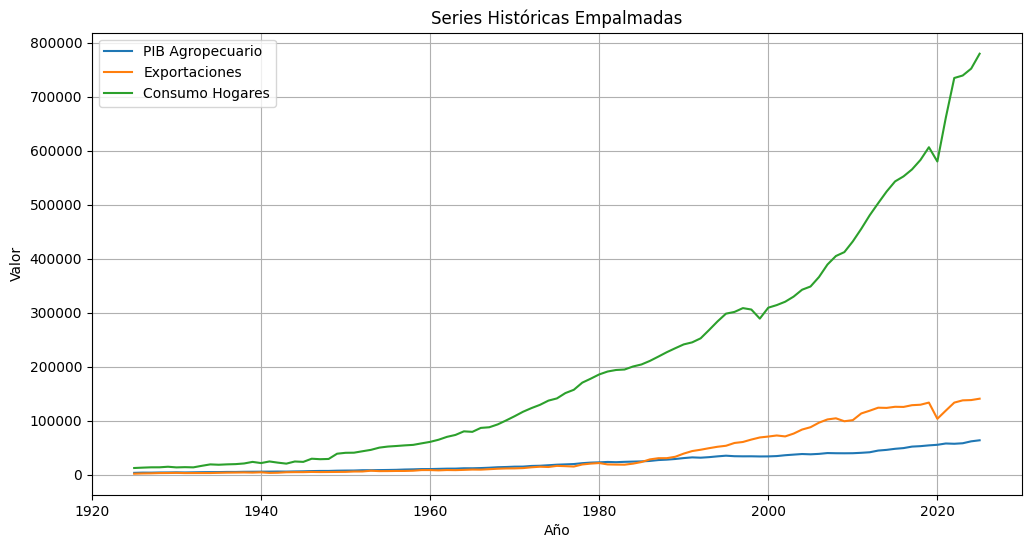

In [31]:
# graficamos la series finales en un mismo plano

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df_final['Año'], df_final['Valor_Agro'], label='PIB Agropecuario')
plt.plot(df_final['Año'], df_final['Valor_Exportaciones'], label='Exportaciones')
plt.plot(df_final['Año'], df_final['Valor_Consumo'], label='Consumo Hogares')
plt.xlabel('Año')
plt.ylabel('Valor')
plt.title('Series Históricas Empalmadas')
plt.legend()
plt.grid()
plt.show()


# Union con datos de Asesinatos selectivos en el conflicto armado.

vamos a unir el df que creamos anteriormente con el df de asesinatos selectivos, para esto filtraremos la base de Asesinatos Colectivos del Centro de Memoria Histórica de Colombia

Se elimina el dato del Año 0 y de 2025 de la serie de asesinatos, debido a el año 0 refiere a eventos donde no se pudo terminar la fecha y el dato de 2025 esta incompleto porque la base corte 2025 en septiembre, osea que no se habían registrado todos los homicidios de ese año.

In [32]:
import pandas as pd
df =pd.read_excel('CasosAS_202509.xlsx')

C:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [33]:
# sumamos por Año y la variable Total de Víctimas del Caso
df_as = df.groupby('Año')['Total de Víctimas del Caso'].sum().reset_index()
df_as.rename(columns={'Total de Víctimas del Caso': 'Victimas_AS'}, inplace=True)
# TOTAL 0
total_victimas = df['Total de Víctimas del Caso'].sum()
victimas_anio_0 = df.loc[df['Año'] == 0, 'Total de Víctimas del Caso'].sum()

porcentaje_victimas_anio_0 = 100 * victimas_anio_0 / total_victimas
porcentaje_victimas_anio_0

# Como solo representan el 0.9% del total, decidimos eliminar
#  el año 0 y quedarnos con los datos desde 1950 en adelante
# eliminamos el año 0 y
df_as = df_as[df_as['Año'] != 0].copy()
df_as = df_as[df_as['Año'] != 2025].copy()


# union de las bases
Ahora unimos los dos df que hemos creado y mantenemos los años de 1925 a 2025

In [34]:
# verificamos el que Año este en las dos bases
df_final['Año'] = df_final['Año'].astype(int)
df_as['Año'] = df_as['Año'].astype(int)
# Check the first few rows of both DataFrames to confirm the data types and values match
print("df_final:")
print(df_final[['Año']].head())
print("\ndf_as:")
print(df_as[['Año']].head())

df_final:
    Año
0  1925
1  1926
2  1927
3  1928
4  1929

df_as:
    Año
1  1944
2  1945
3  1946
4  1947
5  1948


In [35]:
# teniendo en cuenta eso, hacemos una union de los dos DF
# eliminar columnas de víctimas que puedan causar conflictos de sufijos
cols_conflict = [c for c in ['Victimas_AS', 'Victimas_AS_x', 'Victimas_AS_y'] if c in df_final.columns]
if cols_conflict:
    df_final = df_final.drop(columns=cols_conflict)

# unir por año (df_as contiene 'Año' y 'Victimas_AS')
df_final = df_final.merge(df_as, on='Año', how='outer')

# opcional: reordenar columnas si existe 'Victimas_AS'
if 'Victimas_AS' in df_final.columns:
    cols = ['Año', 'Valor_Agro', 'Valor_Consumo', 'Valor_Exportaciones', 'Victimas_AS']
    df_final = df_final[[c for c in cols if c in df_final.columns]].copy()


Ahora descargamos la base de datos completa

In [36]:
df_final.to_csv('BaseDatosFinal.csv', index=False)